# Deforestación en Bolivia y Colombia 2022–2026 — ETL & EDA

**Dataset:** Global Forest Watch — `gfw_integrated_alerts`  
**Países:** Bolivia (BOL), Colombia (COL)  
**Período:** 2022-01-01 → 2026-07-30 | **Filas:** 1,523,990 | **Columnas:** 12 originales + 8 derivadas

```
GFW API → CSV por país → PostgreSQL → EDA + Visualizaciones
```


## 1. Imports y configuración

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

load_dotenv(Path('../.env'))

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 130

START_DATE = '2022-01-01'
END_DATE   = '2026-07-31'

COUNTRIES = {
    'BOL': {'name': 'Bolivia',  'csv': Path(f'../data/csv/bol_alerts_{START_DATE}_{END_DATE}.csv')},
    'COL': {'name': 'Colombia', 'csv': Path(f'../data/csv/col_alerts_{START_DATE}_{END_DATE}.csv')},
}

# --- Conexión PostgreSQL ---
# Configura en .env: PG_USER, PG_PASSWORD, PG_HOST, PG_PORT, PG_DB
# O usa los valores por defecto de abajo
PG_USER     = os.getenv('PG_USER',     'postgres')
PG_PASSWORD = os.getenv('PG_PASSWORD', 'postgres')
PG_HOST     = os.getenv('PG_HOST',     'localhost')
PG_PORT     = os.getenv('PG_PORT',     '5432')
PG_DB       = os.getenv('PG_DB',       'deforestation')

DB_URL = f'postgresql+psycopg2://{PG_USER}:{PG_PASSWORD}@{PG_HOST}:{PG_PORT}/{PG_DB}'
engine = create_engine(DB_URL)

RES_PATH = Path('../data/results')
RES_PATH.mkdir(parents=True, exist_ok=True)
TABLE = 'deforestation_alerts'

print('Librerias cargadas')
for code, info in COUNTRIES.items():
    status = 'OK' if info['csv'].exists() else 'NO ENCONTRADO'
    print(f'  {code}: {info["csv"]}  {status}')
print(f'\nPostgreSQL: {PG_HOST}:{PG_PORT}/{PG_DB}')


ModuleNotFoundError: No module named 'dotenv'

## 2. Carga de CSVs y exploración inicial

In [ ]:
frames = {}
for code, info in COUNTRIES.items():
    df_tmp = pd.read_csv(info['csv'], parse_dates=['gfw_integrated_alerts__date'])
    frames[code] = df_tmp
    print(f"{info['name']:10s} ({code}): {len(df_tmp):>10,} filas | {df_tmp.shape[1]} columnas")

print(f"\nTotal filas: {sum(len(f) for f in frames.values()):,}")
print("\nColumnas originales:")
print(list(frames['BOL'].columns))
frames['BOL'].head(3)


Bolivia    (BOL):    724,000 filas | 12 columnas
Colombia   (COL):    799,990 filas | 12 columnas

Total filas: 1,523,990

Columnas originales:
['latitude', 'longitude', 'gfw_integrated_alerts__date', 'gfw_integrated_alerts__confidence', 'gfw_integrated_alerts__intensity', 'umd_tree_cover_density_2000__percent', 'is__umd_regional_primary_forest_2001', 'wdpa_protected_areas__iucn_cat', 'esa_land_cover_2015__class', 'wri_google_tree_cover_loss_drivers__category', 'gadm_administrative_boundaries__adm1', 'is__umd_soy_planted_area_buffered_10km']


,latitude,longitude,gfw_integrated_alerts__date,gfw_integrated_alerts__confidence,gfw_integrated_alerts__intensity,umd_tree_cover_density_2000__percent,is__umd_regional_primary_forest_2001,wdpa_protected_areas__iucn_cat,esa_land_cover_2015__class,wri_google_tree_cover_loss_drivers__category,gadm_administrative_boundaries__adm1,is__umd_soy_planted_area_buffered_10km
0,-13.03755,-68.11865,2022-01-02,highest,55,99,1,0,Agriculture,5,4,0
1,-13.03795,-68.11835,2022-01-02,highest,55,99,1,0,Agriculture,5,4,0
2,-13.03825,-68.11765,2022-01-02,highest,55,99,1,0,Agriculture,5,4,0


## 3. Calidad de datos

In [ ]:
for code, df_tmp in frames.items():
    nulls    = df_tmp.isnull().sum()
    null_pct = (nulls / len(df_tmp) * 100).round(2)
    quality  = pd.DataFrame({'nulls': nulls, 'null_%': null_pct})
    dups     = df_tmp.duplicated().sum()
    date_col = 'gfw_integrated_alerts__date'
    print(f"\n── {COUNTRIES[code]['name']} ({code}) ──")
    print('Valores nulos:')
    print(quality[quality['nulls'] > 0] if quality['nulls'].sum() > 0 else '  Sin valores nulos')
    print(f'Duplicados: {dups:,}')
    print(f'Rango de fechas: {df_tmp[date_col].min().date()} → {df_tmp[date_col].max().date()}')
    print(f'Confianza unica: {sorted(df_tmp["gfw_integrated_alerts__confidence"].unique())}')



── Bolivia (BOL) ──
Valores nulos:
                            nulls  null_%
esa_land_cover_2015__class    174    0.02
Duplicados: 0
Rango de fechas: 2022-01-01 → 2026-07-30
Confianza unica: ['high', 'highest', 'nominal']

── Colombia (COL) ──
Valores nulos:
                            nulls  null_%
esa_land_cover_2015__class  27037    3.38
Duplicados: 0
Rango de fechas: 2022-01-01 → 2026-07-30
Confianza unica: ['high', 'highest', 'nominal']


## 4. Transformación y limpieza

In [ ]:
# Drivers reales del dataset GFW (código numérico → nombre)
DRIVER_NAMES = {
    1: 'Agricultura',
    2: 'Ganaderia',
    3: 'Silvicultura',
    4: 'Mineria',
    5: 'Infraestructura',
    6: 'Incendios',
    7: 'Otro',
    255: 'Sin clasificar',
}

ADM1_BOL = {
    1: 'Chuquisaca', 2: 'Cochabamba', 3: 'Beni',
    4: 'La Paz',     6: 'Pando',      8: 'Santa Cruz',
    9: 'Tarija',
}

ADM1_COL = {
    1: 'Amazonas',      2: 'Antioquia',     3: 'Arauca',
    4: 'Atlantico',     5: 'Bolivar',       6: 'Boyaca',
    7: 'Caldas',        8: 'Caqueta',       9: 'Casanare',
    10: 'Cauca',        11: 'Cesar',        12: 'Choco',
    13: 'Cordoba',      14: 'Cundinamarca', 15: 'Guainia',
    16: 'Guaviare',     17: 'Huila',        18: 'La Guajira',
    19: 'Magdalena',    20: 'Meta',         21: 'Narino',
    22: 'Norte de Santander', 23: 'Putumayo', 24: 'Quindio',
    25: 'Risaralda',    26: 'San Andres',   27: 'Santander',
    28: 'Sucre',        29: 'Tolima',       30: 'Valle del Cauca',
    31: 'Vaupes',       32: 'Vichada',      33: 'Bogota D.C.',
}

ADM1_NAMES = {'BOL': ADM1_BOL, 'COL': ADM1_COL}

def transform(df_raw, country_code):
    df = df_raw.copy()
    df.columns = [
        'latitude', 'longitude', 'date', 'confidence', 'intensity',
        'tree_cover_density_pct', 'is_primary_forest', 'protected_area_cat',
        'land_cover_class', 'loss_driver_category', 'adm1_code', 'is_soy_area'
    ]
    df['year']               = df['date'].dt.year
    df['month']              = df['date'].dt.month
    df['week']               = df['date'].dt.isocalendar().week.astype(int)
    df['month_name']         = df['date'].dt.strftime('%b')
    df['is_high_confidence'] = df['confidence'].isin(['high', 'highest']).astype(int)
    df['country_code']       = country_code
    df['country_name']       = COUNTRIES[country_code]['name']
    df['adm1_name']          = df['adm1_code'].map(ADM1_NAMES[country_code]).fillna('Desconocido')
    df['loss_driver']        = df['loss_driver_category'].map(DRIVER_NAMES).fillna('Sin clasificar')
    return df

dfs = {code: transform(frames[code], code) for code in COUNTRIES}

for code, df in dfs.items():
    print(f"{COUNTRIES[code]['name']:10s}: {df.shape[0]:>10,} filas x {df.shape[1]} columnas")

dfs['BOL'].head(3)


Bolivia   :    724,000 filas x 21 columnas
Colombia  :    799,990 filas x 21 columnas


,latitude,longitude,date,confidence,intensity,tree_cover_density_pct,is_primary_forest,protected_area_cat,land_cover_class,loss_driver_category,...,is_soy_area,year,month,week,month_name,is_high_confidence,country_code,country_name,adm1_name,loss_driver
0,-13.03755,-68.11865,2022-01-02,highest,55,99,1,0,Agriculture,5,...,0,2022,1,52,Jan,1,BOL,Bolivia,La Paz,Infraestructura
1,-13.03795,-68.11835,2022-01-02,highest,55,99,1,0,Agriculture,5,...,0,2022,1,52,Jan,1,BOL,Bolivia,La Paz,Infraestructura
2,-13.03825,-68.11765,2022-01-02,highest,55,99,1,0,Agriculture,5,...,0,2022,1,52,Jan,1,BOL,Bolivia,La Paz,Infraestructura


## 5. Migración a PostgreSQL — Star Schema

```
dim_date (1,321)      dim_location (45)     dim_driver (8)
dim_land_cover (10)   dim_confidence (3)
         └──────────── fact_alerts (1,523,990) ────────────┘
```

> Prerequisito: `psql -U <user> -c "CREATE DATABASE deforestation;"`


In [ ]:
DRIVER_MAP = {
    1: 'Agricultura', 2: 'Ganaderia', 3: 'Silvicultura', 4: 'Mineria',
    5: 'Infraestructura', 6: 'Incendios', 7: 'Otro', 255: 'Sin clasificar',
}
ADM1_BOL = {
    1:'Chuquisaca', 2:'Cochabamba', 3:'Beni', 4:'La Paz',
    6:'Pando', 8:'Santa Cruz', 9:'Tarija',
}
ADM1_COL = {
    1:'Amazonas', 2:'Antioquia', 3:'Arauca', 4:'Atlantico', 5:'Bolivar',
    6:'Boyaca', 7:'Caldas', 8:'Caqueta', 9:'Casanare', 10:'Cauca',
    11:'Cesar', 12:'Choco', 13:'Cordoba', 14:'Cundinamarca', 15:'Guainia',
    16:'Guaviare', 17:'Huila', 18:'La Guajira', 19:'Magdalena', 20:'Meta',
    21:'Narino', 22:'Norte de Santander', 23:'Putumayo', 24:'Quindio',
    25:'Risaralda', 26:'San Andres', 27:'Santander', 28:'Sucre',
    29:'Tolima', 30:'Valle del Cauca', 31:'Vaupes', 32:'Vichada', 33:'Bogota D.C.',
}
COUNTRY_MAP = {'BOL': ('Bolivia', ADM1_BOL), 'COL': ('Colombia', ADM1_COL)}

# ── Cargar CSVs raw ──────────────────────────────────────────────────────────
frames = {}
for code, info in COUNTRIES.items():
    df = pd.read_csv(info['csv'], parse_dates=['gfw_integrated_alerts__date'])
    df['country_code'] = code
    frames[code] = df
raw = pd.concat(frames.values(), ignore_index=True)
raw.columns = [
    'latitude','longitude','date','confidence','intensity',
    'tree_cover_density_pct','is_primary_forest','protected_area_cat',
    'land_cover_class','loss_driver_category','adm1_code','is_soy_area','country_code'
]
print(f'Raw: {len(raw):,} filas')

# ── dim_date ─────────────────────────────────────────────────────────────────
dim_date = (
    raw[['date']].drop_duplicates()
    .assign(
        year       = lambda d: d['date'].dt.year,
        month      = lambda d: d['date'].dt.month,
        week       = lambda d: d['date'].dt.isocalendar().week.astype(int),
        month_name = lambda d: d['date'].dt.strftime('%b'),
    )
    .sort_values('date')
    .reset_index(drop=True)
)
dim_date.index.name = 'date_id'
dim_date = dim_date.reset_index()
print(f'dim_date:       {len(dim_date):>6,} filas')

# ── dim_location ─────────────────────────────────────────────────────────────
def make_location_rows():
    rows = []
    for code, (name, adm1_map) in COUNTRY_MAP.items():
        for adm1_id, adm1_name in adm1_map.items():
            rows.append({'country_code': code, 'country_name': name,
                         'adm1_code': adm1_id, 'adm1_name': adm1_name})
        rows.append({'country_code': code, 'country_name': name,
                     'adm1_code': -1, 'adm1_name': 'Desconocido'})
    return rows

dim_location = pd.DataFrame(make_location_rows()).reset_index()
dim_location.rename(columns={'index': 'location_id'}, inplace=True)
print(f'dim_location:   {len(dim_location):>6,} filas')

# ── dim_driver ───────────────────────────────────────────────────────────────
dim_driver = pd.DataFrame([
    {'driver_id': k, 'driver_name': v} for k, v in DRIVER_MAP.items()
])
print(f'dim_driver:     {len(dim_driver):>6,} filas')

# ── dim_land_cover ───────────────────────────────────────────────────────────
land_vals = sorted(raw['land_cover_class'].dropna().unique())
dim_land_cover = pd.DataFrame({
    'land_cover_id':    range(len(land_vals)),
    'land_cover_class': land_vals,
})
print(f'dim_land_cover: {len(dim_land_cover):>6,} filas')

# ── dim_confidence ───────────────────────────────────────────────────────────
conf_vals = sorted(raw['confidence'].unique())
dim_confidence = pd.DataFrame({
    'confidence_id':    range(len(conf_vals)),
    'confidence':       conf_vals,
    'is_high_confidence': [1 if c in ('high','highest') else 0 for c in conf_vals],
})
print(f'dim_confidence: {len(dim_confidence):>6,} filas')

# ── fact_alerts: resolver FKs ─────────────────────────────────────────────────
date_map  = dim_date.set_index('date')['date_id']
loc_map   = dim_location.set_index(['country_code','adm1_code'])['location_id']
lc_map    = dim_land_cover.set_index('land_cover_class')['land_cover_id']
conf_map  = dim_confidence.set_index('confidence')['confidence_id']

valid_locs = set(loc_map.index)
fact = raw.copy()
fact['adm1_code_clean'] = fact.apply(
    lambda r: r['adm1_code'] if (r['country_code'], r['adm1_code']) in valid_locs else -1,
    axis=1
)
fact['date_id']       = fact['date'].map(date_map)
fact['location_id']   = pd.MultiIndex.from_arrays(
    [fact['country_code'], fact['adm1_code_clean']]).map(loc_map)
fact['driver_id']     = fact['loss_driver_category'].astype('Int64')
fact['land_cover_id'] = fact['land_cover_class'].map(lc_map)
fact['confidence_id'] = fact['confidence'].map(conf_map)

fact_alerts = fact[[
    'date_id','location_id','driver_id','land_cover_id','confidence_id',
    'latitude','longitude','tree_cover_density_pct','is_primary_forest',
    'protected_area_cat','is_soy_area'
]].copy()
print(f'fact_alerts:    {len(fact_alerts):>6,} filas')

# ── DDL: crear tablas con PK, FK y comentarios ───────────────────────────────
DDL = """
-- Dimensión fecha
DROP TABLE IF EXISTS fact_alerts   CASCADE;
DROP TABLE IF EXISTS dim_date      CASCADE;
DROP TABLE IF EXISTS dim_location  CASCADE;
DROP TABLE IF EXISTS dim_driver    CASCADE;
DROP TABLE IF EXISTS dim_land_cover CASCADE;
DROP TABLE IF EXISTS dim_confidence CASCADE;

CREATE TABLE dim_date (
    date_id    SERIAL      PRIMARY KEY,
    date       DATE        NOT NULL UNIQUE,
    year       SMALLINT    NOT NULL,
    month      SMALLINT    NOT NULL,
    week       SMALLINT    NOT NULL,
    month_name VARCHAR(3)  NOT NULL
);
COMMENT ON TABLE  dim_date            IS 'Dimensión temporal: una fila por fecha de alerta';
COMMENT ON COLUMN dim_date.date_id    IS 'Clave primaria surrogate';
COMMENT ON COLUMN dim_date.date       IS 'Fecha de detección de la alerta (YYYY-MM-DD)';
COMMENT ON COLUMN dim_date.year       IS 'Año calendario';
COMMENT ON COLUMN dim_date.month      IS 'Mes (1–12)';
COMMENT ON COLUMN dim_date.week       IS 'Semana ISO del año';
COMMENT ON COLUMN dim_date.month_name IS 'Abreviatura del mes (Jan, Feb, …)';

CREATE TABLE dim_location (
    location_id  SERIAL      PRIMARY KEY,
    country_code CHAR(3)     NOT NULL,
    country_name VARCHAR(50) NOT NULL,
    adm1_code    SMALLINT    NOT NULL,
    adm1_name    VARCHAR(60) NOT NULL,
    UNIQUE (country_code, adm1_code)
);
COMMENT ON TABLE  dim_location              IS 'Dimensión geográfica: país + departamento/región nivel 1';
COMMENT ON COLUMN dim_location.location_id  IS 'Clave primaria surrogate';
COMMENT ON COLUMN dim_location.country_code IS 'Código ISO-3 del país (BOL, COL)';
COMMENT ON COLUMN dim_location.country_name IS 'Nombre completo del país';
COMMENT ON COLUMN dim_location.adm1_code    IS 'ID GADM del departamento; -1 = sin mapeo válido';
COMMENT ON COLUMN dim_location.adm1_name    IS 'Nombre del departamento; Desconocido si adm1_code = -1';

CREATE TABLE dim_driver (
    driver_id   SMALLINT    PRIMARY KEY,
    driver_name VARCHAR(30) NOT NULL
);
COMMENT ON TABLE  dim_driver             IS 'Dimensión de causas de pérdida forestal (WRI/Google)';
COMMENT ON COLUMN dim_driver.driver_id   IS 'Código numérico original de la API (1–7, 255)';
COMMENT ON COLUMN dim_driver.driver_name IS 'Nombre legible del driver (Agricultura, Minería, …)';

CREATE TABLE dim_land_cover (
    land_cover_id    SMALLINT    PRIMARY KEY,
    land_cover_class VARCHAR(60) NOT NULL UNIQUE
);
COMMENT ON TABLE  dim_land_cover                  IS 'Dimensión de clases de uso del suelo (ESA 2015)';
COMMENT ON COLUMN dim_land_cover.land_cover_id    IS 'Clave primaria surrogate (0-based)';
COMMENT ON COLUMN dim_land_cover.land_cover_class IS 'Clase de cobertura del suelo según ESA Land Cover 2015';

CREATE TABLE dim_confidence (
    confidence_id       SMALLINT    PRIMARY KEY,
    confidence          VARCHAR(10) NOT NULL UNIQUE,
    is_high_confidence  SMALLINT    NOT NULL
);
COMMENT ON TABLE  dim_confidence                     IS 'Dimensión de nivel de confianza de la alerta integrada GFW';
COMMENT ON COLUMN dim_confidence.confidence_id       IS 'Clave primaria surrogate (0-based)';
COMMENT ON COLUMN dim_confidence.confidence          IS 'Nivel de confianza: nominal, high, highest';
COMMENT ON COLUMN dim_confidence.is_high_confidence  IS '1 si confidence IN (high, highest), 0 si nominal';

CREATE TABLE fact_alerts (
    alert_id              BIGSERIAL   PRIMARY KEY,
    date_id               INT         NOT NULL REFERENCES dim_date(date_id),
    location_id           INT         NOT NULL REFERENCES dim_location(location_id),
    driver_id             SMALLINT    NOT NULL REFERENCES dim_driver(driver_id),
    land_cover_id         SMALLINT             REFERENCES dim_land_cover(land_cover_id),
    confidence_id         SMALLINT    NOT NULL REFERENCES dim_confidence(confidence_id),
    latitude              FLOAT       NOT NULL,
    longitude             FLOAT       NOT NULL,
    tree_cover_density_pct SMALLINT,
    is_primary_forest     SMALLINT,
    protected_area_cat    SMALLINT,
    is_soy_area           SMALLINT
);
COMMENT ON TABLE  fact_alerts                        IS 'Tabla de hechos: una fila por alerta de deforestación detectada';
COMMENT ON COLUMN fact_alerts.alert_id               IS 'Clave primaria surrogate (autoincremental)';
COMMENT ON COLUMN fact_alerts.date_id                IS 'FK → dim_date: fecha de detección';
COMMENT ON COLUMN fact_alerts.location_id            IS 'FK → dim_location: país y departamento';
COMMENT ON COLUMN fact_alerts.driver_id              IS 'FK → dim_driver: causa de pérdida forestal';
COMMENT ON COLUMN fact_alerts.land_cover_id          IS 'FK → dim_land_cover: clase de uso del suelo (nullable si ESA sin dato)';
COMMENT ON COLUMN fact_alerts.confidence_id          IS 'FK → dim_confidence: nivel de confianza de la alerta';
COMMENT ON COLUMN fact_alerts.latitude               IS 'Latitud del centroide del píxel de alerta';
COMMENT ON COLUMN fact_alerts.longitude              IS 'Longitud del centroide del píxel de alerta';
COMMENT ON COLUMN fact_alerts.tree_cover_density_pct IS 'Densidad de cobertura arbórea en el año 2000 (0–100 %)';
COMMENT ON COLUMN fact_alerts.is_primary_forest      IS '1 si el píxel era bosque primario en 2001 según UMD';
COMMENT ON COLUMN fact_alerts.protected_area_cat     IS 'Categoría IUCN del área protegida; 0 = no protegida';
COMMENT ON COLUMN fact_alerts.is_soy_area            IS '1 si el píxel está dentro de 10 km de área de cultivo de soya';
"""

with engine.connect() as conn:
    conn.execute(text(DDL))
    conn.commit()
print('Esquema creado con PK, FK y comentarios')

# ── Cargar datos a PostgreSQL ─────────────────────────────────────────────────
# Dimensiones primero (sin FKs entrantes), luego fact_alerts
dim_date.to_sql('dim_date', engine, if_exists='append', index=False,
                chunksize=10_000, method='multi')
print(f'  dim_date        -> {len(dim_date):,} filas')

dim_location.to_sql('dim_location', engine, if_exists='append', index=False,
                     chunksize=10_000, method='multi')
print(f'  dim_location    -> {len(dim_location):,} filas')

dim_driver.to_sql('dim_driver', engine, if_exists='append', index=False,
                   chunksize=10_000, method='multi')
print(f'  dim_driver      -> {len(dim_driver):,} filas')

dim_land_cover.to_sql('dim_land_cover', engine, if_exists='append', index=False,
                       chunksize=10_000, method='multi')
print(f'  dim_land_cover  -> {len(dim_land_cover):,} filas')

dim_confidence.to_sql('dim_confidence', engine, if_exists='append', index=False,
                       chunksize=10_000, method='multi')
print(f'  dim_confidence  -> {len(dim_confidence):,} filas')

fact_alerts.to_sql('fact_alerts', engine, if_exists='append', index=False,
                    chunksize=10_000, method='multi')
print(f'  fact_alerts     -> {len(fact_alerts):,} filas')

# ── Índices adicionales en fact_alerts ───────────────────────────────────────
with engine.connect() as conn:
    for idx, col in [
        ('idx_fact_date',       'fact_alerts(date_id)'),
        ('idx_fact_location',   'fact_alerts(location_id)'),
        ('idx_fact_driver',     'fact_alerts(driver_id)'),
        ('idx_fact_land_cover', 'fact_alerts(land_cover_id)'),
        ('idx_fact_confidence', 'fact_alerts(confidence_id)'),
    ]:
        conn.execute(text(f'CREATE INDEX IF NOT EXISTS {idx} ON {col}'))
    conn.commit()
print('Índices creados')


Raw: 1,523,990 filas
dim_date:        1,321 filas
dim_location:       42 filas
dim_driver:          8 filas
dim_land_cover:     10 filas
dim_confidence:      3 filas
fact_alerts:    1,523,990 filas
Esquema creado con PK, FK y comentarios
  dim_date        -> 1,321 filas
  dim_location    -> 42 filas
  dim_driver      -> 8 filas
  dim_land_cover  -> 10 filas
  dim_confidence  -> 3 filas
  fact_alerts     -> 1,523,990 filas
Índices creados


## 6. EDA desde base de datos
> Todas las consultas usan SQL con Joins.


In [ ]:
def query(sql):
    return pd.read_sql_query(sql, engine)

# Alias para joins frecuentes
JOINS = """
    JOIN dim_date       d  ON f.date_id       = d.date_id
    JOIN dim_location   l  ON f.location_id   = l.location_id
    JOIN dim_driver     dr ON f.driver_id      = dr.driver_id
    JOIN dim_land_cover lc ON f.land_cover_id  = lc.land_cover_id
    JOIN dim_confidence c  ON f.confidence_id  = c.confidence_id
"""


In [ ]:
q_country = query(f"""
    SELECT l.country_name, l.country_code,
           COUNT(*) AS alerts,
           ROUND(AVG(f.tree_cover_density_pct)::numeric, 1) AS avg_tcd,
           ROUND(100.0 * SUM(c.is_high_confidence) / COUNT(*), 1) AS pct_high_conf
    FROM fact_alerts f
    JOIN dim_location   l ON f.location_id  = l.location_id
    JOIN dim_confidence c ON f.confidence_id = c.confidence_id
    GROUP BY l.country_code, l.country_name
    ORDER BY alerts DESC
""")
print('Resumen por pais:')
print(q_country.to_string(index=False))


Resumen por pais:
country_name country_code  alerts  avg_tcd  pct_high_conf
    Colombia          COL  799990     94.4           94.3
     Bolivia          BOL  724000     96.7           97.1


In [ ]:
q_year_country = query("""
    SELECT d.year, l.country_code, COUNT(*) AS alerts
    FROM fact_alerts f
    JOIN dim_date     d ON f.date_id     = d.date_id
    JOIN dim_location l ON f.location_id = l.location_id
    GROUP BY d.year, l.country_code
    ORDER BY d.year, l.country_code
""")
print('Alertas por anio y pais:')
print(q_year_country.to_string(index=False))


Alertas por anio y pais:
 year country_code  alerts
 2022          BOL  162000
 2022          COL  152474
 2023          BOL  164000
 2023          COL  147526
 2024          BOL  167492
 2024          COL  194000
 2025          BOL  159951
 2025          COL  183371
 2026          BOL   70557
 2026          COL  122619


In [ ]:
q_monthly = query("""
    SELECT d.month, l.country_code, COUNT(*) AS alerts
    FROM fact_alerts f
    JOIN dim_date     d ON f.date_id     = d.date_id
    JOIN dim_location l ON f.location_id = l.location_id
    GROUP BY d.month, l.country_code
    ORDER BY d.month, l.country_code
""")
print('Alertas por mes y pais:')
print(q_monthly.to_string(index=False))


Alertas por mes y pais:
 month country_code  alerts
     1          BOL   41710
     1          COL  113128
     2          BOL   41086
     2          COL  109440
     3          BOL   43864
     3          COL   70184
     4          BOL   41983
     4          COL   49373
     5          BOL   44414
     5          COL   51705
     6          BOL   43816
     6          COL   53819
     7          BOL   96187
     7          COL  100270
     8          BOL   84004
     8          COL   90393
     9          BOL   79947
     9          COL   41451
    10          BOL   88048
    10          COL   40727
    11          BOL   80006
    11          COL   42037
    12          BOL   38935
    12          COL   37463


In [ ]:
q_drivers = query("""
    SELECT l.country_code, dr.driver_name, COUNT(*) AS alerts
    FROM fact_alerts f
    JOIN dim_location l  ON f.location_id = l.location_id
    JOIN dim_driver   dr ON f.driver_id    = dr.driver_id
    GROUP BY l.country_code, dr.driver_name
    ORDER BY l.country_code, alerts DESC
""")
print('Causas de perdida forestal por pais:')
print(q_drivers.to_string(index=False))


Causas de perdida forestal por pais:
country_code     driver_name  alerts
         BOL     Agricultura  310799
         BOL Infraestructura  156680
         BOL            Otro   98671
         BOL  Sin clasificar   70499
         BOL    Silvicultura   41150
         BOL         Mineria   38673
         BOL       Ganaderia    6313
         BOL       Incendios    1215
         COL     Agricultura  475163
         COL  Sin clasificar  125237
         COL    Silvicultura  103116
         COL            Otro   38183
         COL         Mineria   36934
         COL       Ganaderia   19067
         COL Infraestructura    1286
         COL       Incendios    1004


In [ ]:
q_primary = query("""
    SELECT l.country_code, f.is_primary_forest, COUNT(*) AS alerts
    FROM fact_alerts f
    JOIN dim_location l ON f.location_id = l.location_id
    GROUP BY l.country_code, f.is_primary_forest
    ORDER BY l.country_code, f.is_primary_forest DESC
""")
q_primary['tipo'] = q_primary['is_primary_forest'].map({1: 'Bosque primario', 0: 'Bosque secundario'})
print(q_primary[['country_code', 'tipo', 'alerts']].to_string(index=False))


country_code              tipo  alerts
         BOL   Bosque primario  676781
         BOL Bosque secundario   47219
         COL   Bosque primario  640254
         COL Bosque secundario  159736


In [ ]:
q_land = query("""
    SELECT l.country_code, lc.land_cover_class, COUNT(*) AS alerts
    FROM fact_alerts f
    JOIN dim_location   l  ON f.location_id  = l.location_id
    JOIN dim_land_cover lc ON f.land_cover_id = lc.land_cover_id
    GROUP BY l.country_code, lc.land_cover_class
    ORDER BY l.country_code, alerts DESC
""")
print('Cobertura de suelo por pais:')
print(q_land.to_string(index=False))


Cobertura de suelo por pais:
country_code       land_cover_class  alerts
         BOL            Agriculture  675277
         BOL                Wetland   15986
         BOL              Grassland   15000
         BOL                 Forest   13053
         BOL      Sparse vegetation    2266
         BOL                  Water    2174
         BOL              Shrubland      55
         BOL                   Bare      15
         COL            Agriculture  727349
         COL              Grassland   20048
         COL                 Forest    8363
         COL                  Water    5764
         COL      Sparse vegetation    5667
         COL                   Bare    1953
         COL                Wetland    1831
         COL              Shrubland    1366
         COL Permanent snow and ice     596
         COL             Settlement      16


## 7. Visualizaciones

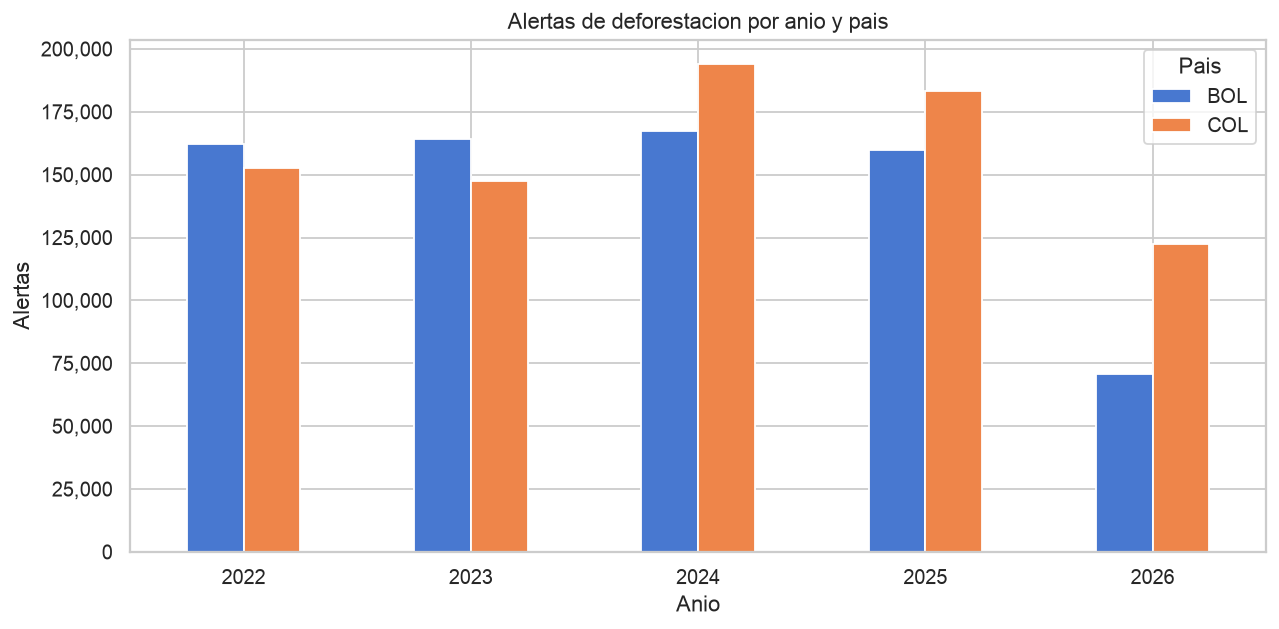

In [ ]:
# Fig 1 — Alertas anuales por pais
pivot_year = q_year_country.pivot(index='year', columns='country_code', values='alerts').fillna(0)

fig, ax = plt.subplots(figsize=(10, 5))
pivot_year.plot(kind='bar', ax=ax)
ax.set_title('Alertas de deforestacion por año y pais')
ax.set_xlabel('Año')
ax.set_ylabel('Alertas')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(title='Pais')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(RES_PATH / 'fig1_alertas_anuales_por_pais.png', dpi=130)
plt.show()


In [ ]:
-# Fig 2 — Estacionalidad mensual por pais
pivot_month = q_monthly.pivot(index='month', columns='country_code', values='alerts').fillna(0)

fig, ax = plt.subplots(figsize=(10, 5))
pivot_month.plot(ax=ax, marker='o')
ax.set_title('Estacionalidad mensual de alertas por pais (2022-2026)')
ax.set_xlabel('Mes')
ax.set_ylabel('Alertas')
ax.set_xticks(range(1, 13))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(title='Pais')
plt.tight_layout()
plt.savefig(RES_PATH / 'fig2_estacionalidad_por_pais.png', dpi=130)
plt.show()


SyntaxError: invalid syntax (138716759.py, line 1)

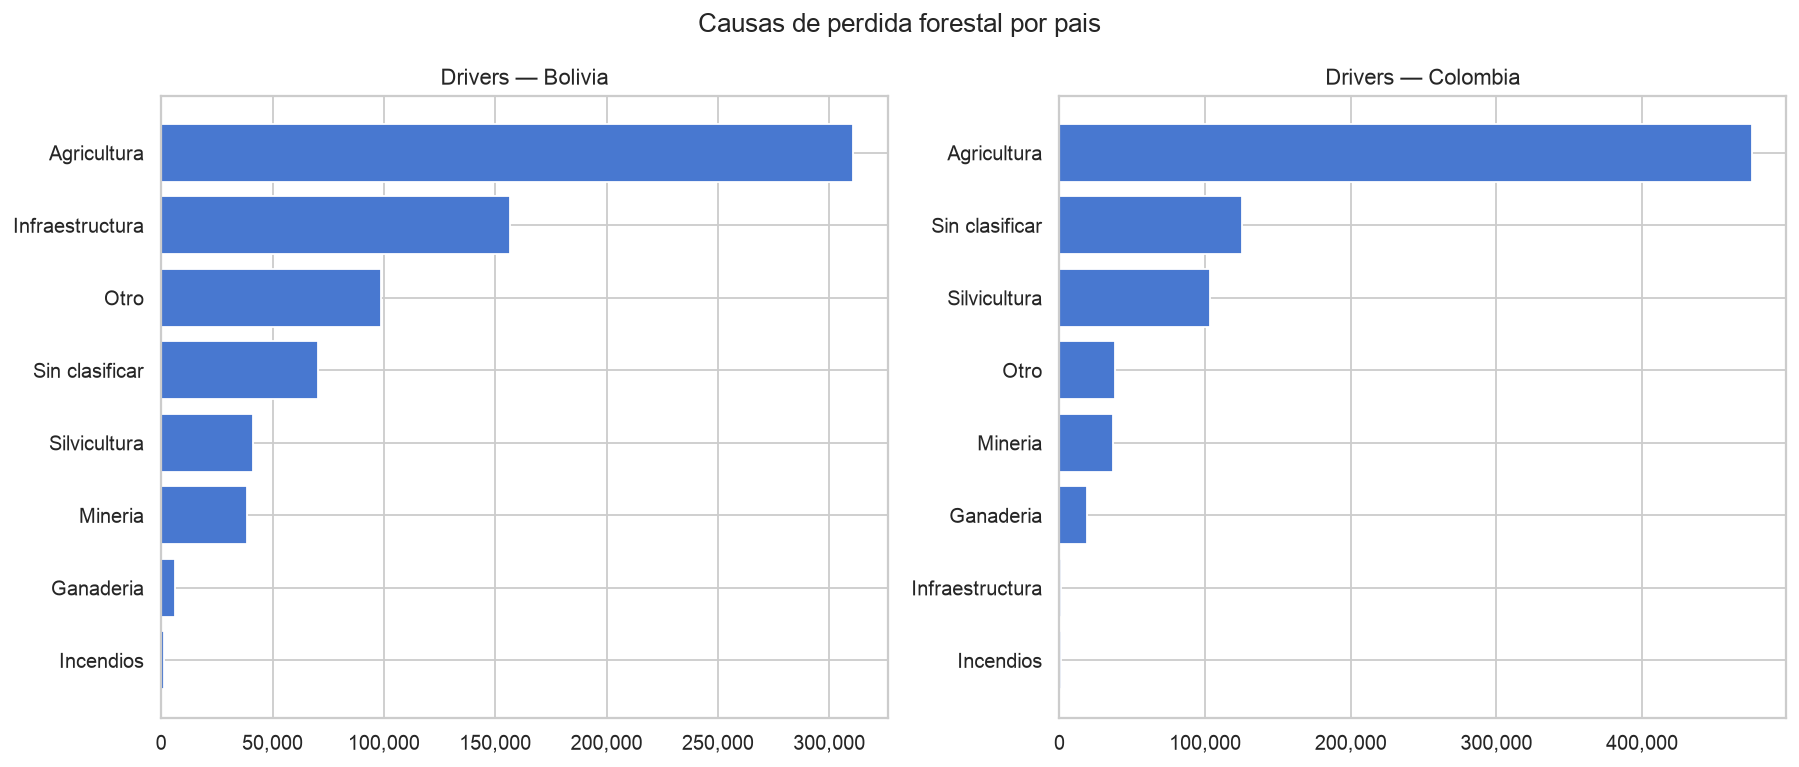

In [ ]:
# Fig 3 — Drivers de perdida forestal por pais
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (code, grp) in zip(axes, q_drivers.groupby('country_code')):
    grp_sorted = grp.sort_values('alerts', ascending=True)
    ax.barh(grp_sorted['driver_name'], grp_sorted['alerts'])
    ax.set_title(f'Drivers — {COUNTRIES[code]["name"]}')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.suptitle('Causas de perdida forestal por pais')
plt.tight_layout()
plt.savefig(RES_PATH / 'fig3_drivers_por_pais.png', dpi=130)
plt.show()


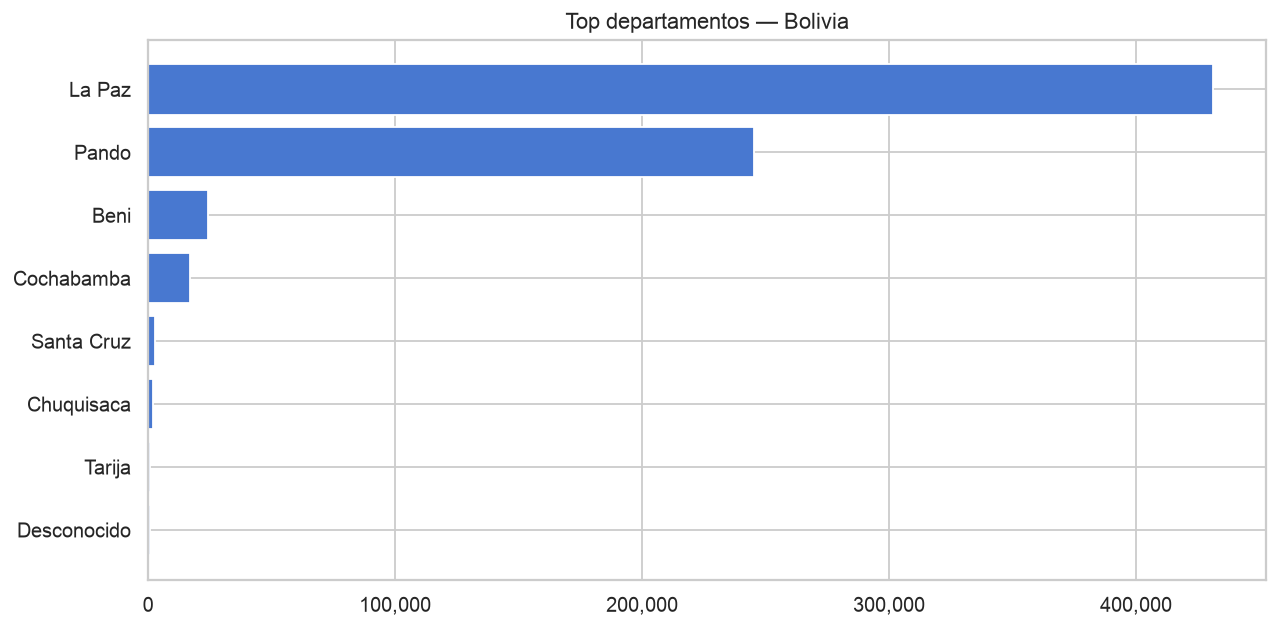

In [ ]:
# Fig 4 — Top departamentos Bolivia
q_bol_adm1 = query("""
    SELECT l.adm1_name, COUNT(*) AS alerts
    FROM fact_alerts f
    JOIN dim_location l ON f.location_id = l.location_id
    WHERE l.country_code = 'BOL'
    GROUP BY l.adm1_name
    ORDER BY alerts DESC
    LIMIT 10
""")
fig, ax = plt.subplots(figsize=(10, 5))
q_bol_adm1_sorted = q_bol_adm1.sort_values('alerts', ascending=True)
ax.barh(q_bol_adm1_sorted['adm1_name'], q_bol_adm1_sorted['alerts'])
ax.set_title('Top departamentos — Bolivia')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(RES_PATH / 'fig4_bol_departamentos.png', dpi=130)
plt.show()


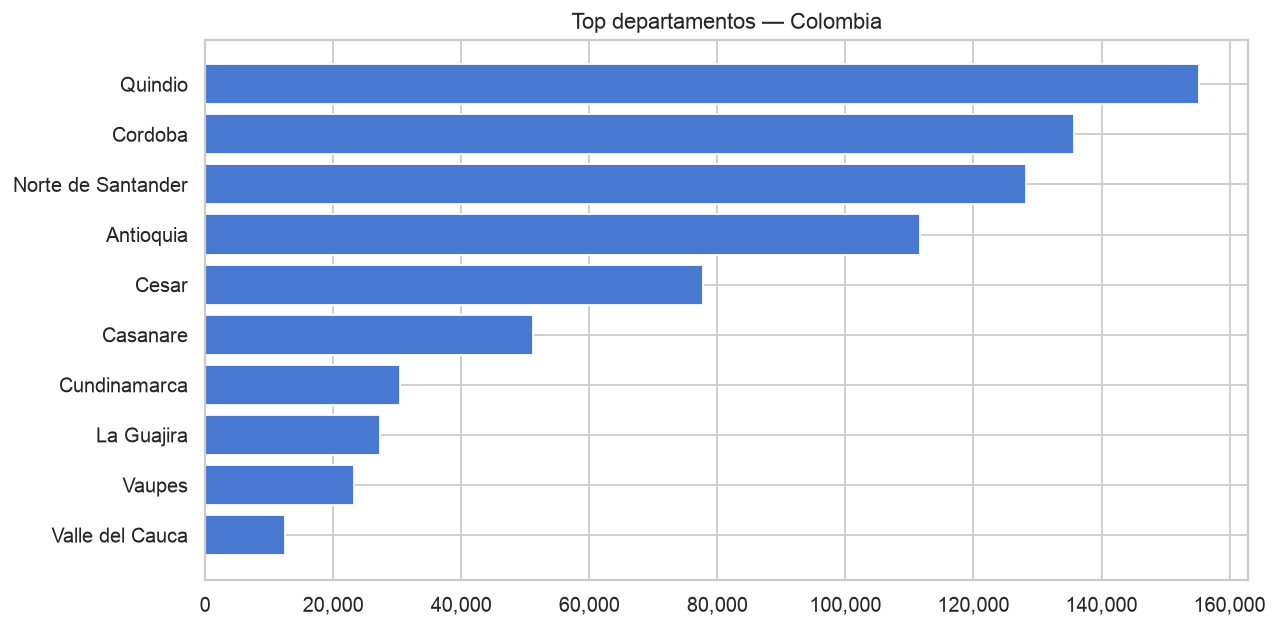

In [ ]:
# Fig 5 — Top departamentos Colombia
q_col_adm1 = query("""
    SELECT l.adm1_name, COUNT(*) AS alerts
    FROM fact_alerts f
    JOIN dim_location l ON f.location_id = l.location_id
    WHERE l.country_code = 'COL'
    GROUP BY l.adm1_name
    ORDER BY alerts DESC
    LIMIT 10
""")
fig, ax = plt.subplots(figsize=(10, 5))
q_col_adm1_sorted = q_col_adm1.sort_values('alerts', ascending=True)
ax.barh(q_col_adm1_sorted['adm1_name'], q_col_adm1_sorted['alerts'])
ax.set_title('Top departamentos — Colombia')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(RES_PATH / 'fig5_col_departamentos.png', dpi=130)
plt.show()


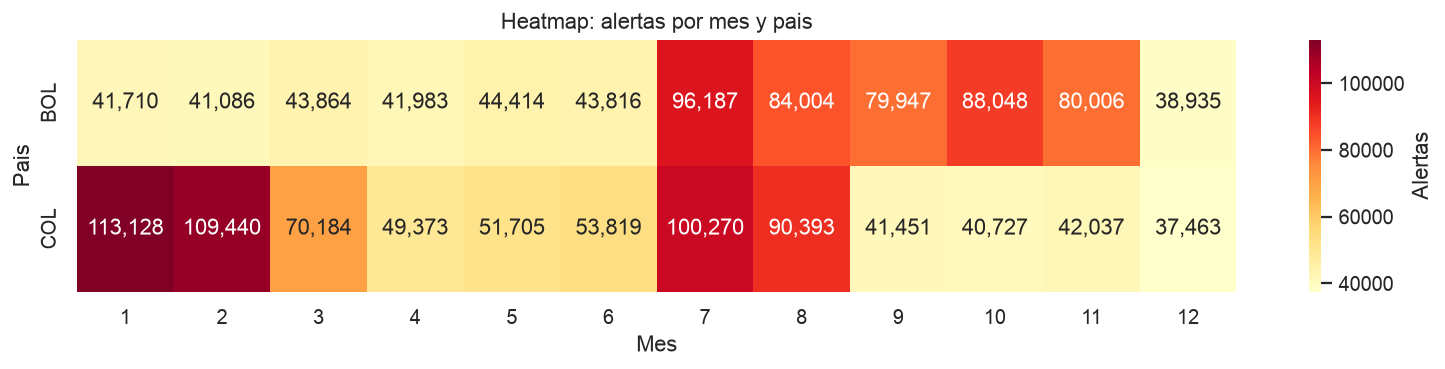

In [ ]:
# Fig 6 — Heatmap mes x pais
q_heat = query("""
    SELECT d.month, l.country_code, COUNT(*) AS alerts
    FROM fact_alerts f
    JOIN dim_date     d ON f.date_id     = d.date_id
    JOIN dim_location l ON f.location_id = l.location_id
    GROUP BY d.month, l.country_code
    ORDER BY d.month, l.country_code
""")
pivot_heat = q_heat.pivot(index='country_code', columns='month', values='alerts')
fig, ax = plt.subplots(figsize=(12, 3))
sns.heatmap(pivot_heat, annot=True, fmt=',d', cmap='YlOrRd', ax=ax,
            cbar_kws={'label': 'Alertas'})
ax.set_title('Heatmap: alertas por mes y pais')
ax.set_xlabel('Mes'); ax.set_ylabel('Pais')
plt.tight_layout()
plt.savefig(RES_PATH / 'fig6_heatmap_mes_pais.png', dpi=130)
plt.show()


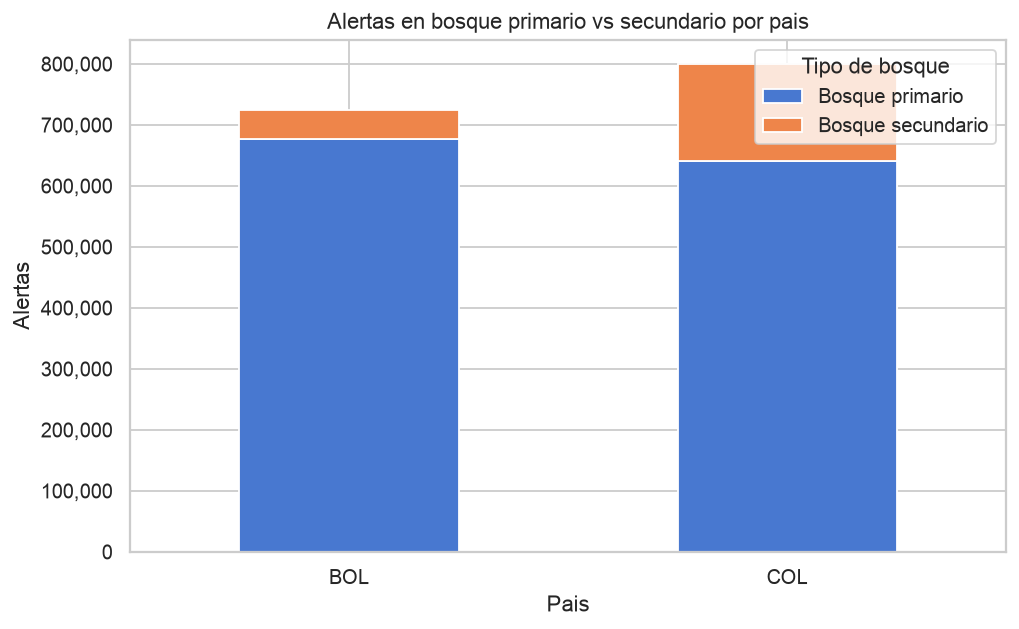

In [ ]:
# Fig 7 — Bosque primario vs secundario por pais
q_primary['tipo'] = q_primary['is_primary_forest'].map({1: 'Bosque primario', 0: 'Bosque secundario'})
pivot_prim = q_primary.pivot(index='country_code', columns='tipo', values='alerts').fillna(0)

fig, ax = plt.subplots(figsize=(8, 5))
pivot_prim.plot(kind='bar', ax=ax, stacked=True)
ax.set_title('Alertas en bosque primario vs secundario por pais')
ax.set_xlabel('Pais')
ax.set_ylabel('Alertas')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(title='Tipo de bosque')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(RES_PATH / 'fig7_bosque_primario_por_pais.png', dpi=130)
plt.show()


## 8. Hallazgos principales

### Tendencias temporales
- Bolivia concentra alertas en meses 7–11 (temporada seca/incendios)
- Colombia concentra alertas en meses 1–2 y 7–8
- Colombia muestra incremento sostenido en 2024–2025 (+31% vs. 2022)
- Bolivia se mantiene relativamente estable entre 2022 y 2025

### Drivers de pérdida forestal
- Agricultura es el driver dominante en ambos países (BOL: 43%, COL: 59%)
- Infraestructura es el segundo driver en Bolivia (22%); Silvicultura en Colombia (13%)
- ~10–16% de alertas sin clasificar (driver 255)

### Cobertura forestal
- Bolivia: 93.5% de alertas en bosque primario
- Colombia: 80.0% de alertas en bosque primario
- Clase de suelo dominante en ambos países: Agriculture (clasificación ESA 2015)

### Calidad de datos
- Nulos: solo en `land_cover_class` — BOL 0.02%, COL 3.38%
- Duplicados: 0 en ambos países
- IDs administrativos anómalos en Bolivia (17, 18, 22, 9999): ~492 registros → mapeados como `Desconocido`
